# Retail Behavior EDA — Full Pre-Metric Analysis

Dataset: `retail_behavior.db` (SQLite) — `stocks`, `shareholding`, `price_data` tables.

Structure follows: **Data Quality → Univariate → Longitudinal → Relational/Confound → Visual Spot-Check**

Place `retail_behavior.db` in the same folder as this notebook before running.

In [4]:
import sqlite3, pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

DB_PATH = "retail_behavior.db"   # <-- change path if needed

con = sqlite3.connect(DB_PATH)
stocks = pd.read_sql('SELECT * FROM stocks', con)
share  = pd.read_sql('SELECT * FROM shareholding', con)
price  = pd.read_sql('SELECT * FROM price_data', con)

share['quarter_end_date'] = pd.to_datetime(share['quarter_end_date'])
share['results_date']     = pd.to_datetime(share['results_date'])
price['trade_date']       = pd.to_datetime(price['trade_date'])

print(stocks.shape, share.shape, price.shape)
stocks.head()

(20, 4) (160, 7) (10000, 7)


,ticker,company_name,sector,expected_retail_tilt
0,HDFCBANK,HDFC Bank,Finance,Low
1,ICICIBANK,ICICI Bank,Finance,Low
2,KOTAKBANK,Kotak Mahindra Bank,Finance,Low
3,BAJFINANCE,Bajaj Finance,Finance,Low
4,BAJAJFINSV,Bajaj Finserv,Finance,Low-Medium


## Data Quality / Sanity Checks

Row counts, nulls, duplicate keys, ownership-sum check, date-range coverage, results_date sanity, zero/negative price-volume, ticker consistency.

In [5]:
print("-- Row counts --")
print("stocks:", len(stocks), "| sector split:", stocks.sector.value_counts().to_dict())
print("shareholding:", len(share), "=", stocks.ticker.nunique(), "tickers x",
      share.groupby('ticker').size().unique(), "quarters each")
print("price_data:", len(price), "| rows per ticker:", price.groupby('ticker').size().unique())

-- Row counts --
stocks: 20 | sector split: {'Finance': 10, 'Manufacturing and Others': 10}
shareholding: 160 = 20 tickers x [8] quarters each
price_data: 10000 | rows per ticker: [500]


In [6]:
print("-- Missing values --")
print("stocks nulls:\n", stocks.isnull().sum(), "\n")
print("shareholding nulls:\n", share.isnull().sum(), "\n")
print("price_data nulls:\n", price.isnull().sum())

-- Missing values --
stocks nulls:
 ticker                  0
company_name            0
sector                  0
expected_retail_tilt    0
dtype: int64 

shareholding nulls:
 ticker                0
quarter_end_date      0
promoter_pct         32
fii_pct               0
dii_pct               0
public_retail_pct     0
results_date          0
dtype: int64 

price_data nulls:
 ticker        0
trade_date    0
open          0
high          0
low           0
close         0
volume        0
dtype: int64


The 4 promoter-null names are genuinely promoter-less widely-held firms

In [7]:
print("-- Duplicate keys --")
print("shareholding dup (ticker,quarter_end_date):", share.duplicated(['ticker','quarter_end_date']).sum())
print("price_data dup (ticker,trade_date):", price.duplicated(['ticker','trade_date']).sum())

-- Duplicate keys --
shareholding dup (ticker,quarter_end_date): 0
price_data dup (ticker,trade_date): 0


In [8]:
print("-- Ownership % sum check (promoter + fii + dii + public_retail) --")
share['own_sum'] = share[['promoter_pct','fii_pct','dii_pct','public_retail_pct']].sum(axis=1, skipna=True)
sum_by_ticker = share.groupby('ticker')['own_sum'].mean().sort_values()
print(sum_by_ticker.round(2))
bad = share[(share['own_sum']<95)|(share['own_sum']>102)]
print("\nRows outside 95-102% band:", len(bad), "| tickers affected:", bad.ticker.unique())

-- Ownership % sum check (promoter + fii + dii + public_retail) --
ticker
IDEA           60.73
IDFCFIRSTB     92.05
TMPV           99.69
ICICIBANK      99.74
LT             99.75
HDFCBANK       99.81
BANKBARODA     99.82
BAJFINANCE     99.85
BAJAJ-AUTO     99.90
BAJAJFINSV     99.90
MARUTI         99.92
ASHOKLEY       99.93
HEROMOTOCO     99.94
BHEL           99.98
YESBANK        99.99
RVNL           99.99
SUZLON         99.99
KOTAKBANK     100.00
PNB           100.00
IIFL          100.00
Name: own_sum, dtype: float64

Rows outside 95-102% band: 15 | tickers affected: ['IDFCFIRSTB' 'IDEA']


IDEA: missing Govt/Others holding bucket (Vodafone Idea genuinely has a large non-split government stake)

In [9]:
print("-- promoter_pct NaN tickers (expected: companies with no identifiable single promoter) --")
nan_prom = share[share['promoter_pct'].isnull()]['ticker'].unique()
print(nan_prom)

print("\n-- Deep dive: IDEA (ownership sum consistently ~50-80%, every quarter) --")
print(share[share.ticker=='IDEA'][['quarter_end_date','promoter_pct','fii_pct','dii_pct','public_retail_pct','own_sum']].to_string(index=False))

print("\n-- Deep dive: IDFCFIRSTB (promoter_pct drops to 0 after merger) --")
print(share[share.ticker=='IDFCFIRSTB'][['quarter_end_date','promoter_pct','fii_pct','dii_pct','public_retail_pct','own_sum']].to_string(index=False))

-- promoter_pct NaN tickers (expected: companies with no identifiable single promoter) --
['HDFCBANK' 'ICICIBANK' 'YESBANK' 'LT']

-- Deep dive: IDEA (ownership sum consistently ~60-67%, every quarter) --
quarter_end_date  promoter_pct  fii_pct  dii_pct  public_retail_pct  own_sum
      2024-09-30         37.32    12.69     4.86              21.94    76.81
      2024-12-31         37.32    10.17     4.28              25.05    76.82
      2025-03-31         38.80    10.10     4.90              23.55    77.35
      2025-06-30         25.57     5.98     4.14              15.28    50.97
      2025-09-30         25.57     5.99     4.74              14.69    50.99
      2025-12-31         25.57     5.99     5.59              13.83    50.98
      2026-03-31         25.64     5.56     6.19              13.57    50.96
      2026-06-30         25.64     6.17     6.05              13.11    50.97

-- Deep dive: IDFCFIRSTB (promoter_pct drops to 0 after merger) --
quarter_end_date  promoter_pct  fi

In [10]:
print("-- Date range coverage: price_data --")
print(price.groupby('ticker')['trade_date'].agg(['min','max','count']))

-- Date range coverage: price_data --
                  min        max  count
ticker                                 
ASHOKLEY   2024-10-03 2026-10-01    500
BAJAJ-AUTO 2024-10-03 2026-10-01    500
BAJAJFINSV 2024-10-03 2026-10-01    500
BAJFINANCE 2024-10-03 2026-10-01    500
BANKBARODA 2024-10-03 2026-10-01    500
BHEL       2024-10-03 2026-10-01    500
HDFCBANK   2024-10-03 2026-10-01    500
HEROMOTOCO 2024-10-03 2026-10-01    500
ICICIBANK  2024-10-03 2026-10-01    500
IDEA       2024-10-03 2026-10-01    500
IDFCFIRSTB 2024-10-03 2026-10-01    500
IIFL       2024-10-03 2026-10-01    500
KOTAKBANK  2024-10-03 2026-10-01    500
LT         2024-10-03 2026-10-01    500
MARUTI     2024-10-03 2026-10-01    500
PNB        2024-10-03 2026-10-01    500
RVNL       2024-10-03 2026-10-01    500
SUZLON     2024-10-03 2026-10-01    500
TMPV       2024-10-03 2026-10-01    500
YESBANK    2024-10-03 2026-10-01    500


In [11]:
print("-- results_date vs quarter_end_date gap --")
share['gap_days'] = (share['results_date'] - share['quarter_end_date']).dt.days
print(share['gap_days'].describe())
print("\nViolations (gap<=0 or >60):", ((share['gap_days']<=0)|(share['gap_days']>60)).sum())

print("\n-- results_date NULL pattern --")
null_res = share[share.results_date.isnull()]
print(null_res.groupby('ticker').size())
print("\nQuarters affected:", null_res.quarter_end_date.dt.to_period('Q').value_counts())

-- results_date vs quarter_end_date gap --
count    160.000000
mean      32.537500
std        9.929239
min       16.000000
25%       25.000000
50%       30.000000
75%       39.000000
max       60.000000
Name: gap_days, dtype: float64

Violations (gap<=0 or >60): 0

-- results_date NULL pattern --
Series([], dtype: int64)

Quarters affected: Series([], Freq: Q-DEC, Name: count, dtype: int64)


In [12]:
print("-- Zero/negative price or volume --")
print("volume<=0:", (price['volume']<=0).sum())
print("close<=0:", (price['close']<=0).sum())
print("high<low (impossible candle):", (price['high']<price['low']).sum())

print("\n-- Are the zero-volume rows stock-specific or market-wide? --")
vz = price[price.volume<=0]
print(vz.trade_date.value_counts().sort_index())
print("\nUnique dates affected:", vz.trade_date.nunique(), "| rows per date:", vz.groupby('trade_date').size().unique())
print("--> Same calendar dates hit ALL 20 tickers simultaneously = market-wide holiday/no-trade day wrongly scraped in, NOT a stock-specific data error.")

-- Zero/negative price or volume --
volume<=0: 120
close<=0: 0
high<low (impossible candle): 0

-- Are the zero-volume rows stock-specific or market-wide? --
trade_date
2025-03-18    20
2026-01-15    20
2026-05-01    20
2026-05-28    20
2026-06-26    20
2026-09-14    20
Name: count, dtype: int64

Unique dates affected: 6 | rows per date: [20]
--> Same calendar dates hit ALL 20 tickers simultaneously = market-wide holiday/no-trade day wrongly scraped in, NOT a stock-specific data error.


In [13]:
print("-- Ticker consistency across all 3 tables --")
print("shareholding tickers not in stocks:", set(share.ticker)-set(stocks.ticker))
print("price_data tickers not in stocks:  ", set(price.ticker)-set(stocks.ticker))
print("stocks tickers missing from shareholding:", set(stocks.ticker)-set(share.ticker))
print("stocks tickers missing from price_data:  ", set(stocks.ticker)-set(price.ticker))

-- Ticker consistency across all 3 tables --
shareholding tickers not in stocks: set()
price_data tickers not in stocks:   set()
stocks tickers missing from shareholding: set()
stocks tickers missing from price_data:   set()


### Result

| Issue  | Handling |
|---|---|
| `promoter_pct` NaN — HDFCBANK, ICICIBANK, YESBANK, LT | Real: these are genuinely promoter-less / widely-held companies. |
| Ownership sum ~50-80% every quarter — IDEA | Real-world: Vodafone Idea has a large Govt/Others holding |
| Ownership sum ~90-93% from 2024-12-31 — IDFCFIRSTB | Real IDFC–IDFC First merger event (promoter→0) |
| Duplicate keys, orphan tickers, bad candles (`high<low`) | Clean. |

In [14]:
# Build the cleaned price table used for every analysis from here on
bad_dates = price.groupby('trade_date')['volume'].apply(lambda s: (s<=0).mean())
bad_dates = bad_dates[bad_dates>0.9].index
price_clean = price[~price.trade_date.isin(bad_dates)].copy().sort_values(['ticker','trade_date']).reset_index(drop=True)
price_clean['ret'] = price_clean.groupby('ticker')['close'].pct_change()

share = share.merge(stocks[['ticker','sector']], on='ticker')
print("Dropped", len(bad_dates), "market-wide bad dates. price_clean shape:", price_clean.shape)

Dropped 6 market-wide bad dates. price_clean shape: (9880, 8)


In [15]:
FIN   = "#1F77B4"
MFG   = "#D62728"
DARKGREY = "#595959"
GREY  = "#B0B0B0"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": False, "figure.facecolor": "white", "axes.facecolor": "white"
})

## `public_retail_pct` distribution

**Why:** the sector median is the number that would define the High/Low bucket split — need to know it precisely and check if sector is even the right split axis.

In [16]:
desc = share.groupby('sector')['public_retail_pct'].describe()[['min','25%','50%','mean','75%','max','std']]
print(desc.round(2))

med_fin = share[share.sector=='Finance']['public_retail_pct'].median()
med_mfg = share[share.sector=='Manufacturing and Others']['public_retail_pct'].median()
print(f"\nMedian retail% -> Finance: {med_fin:.2f}  Manufacturing and Others: {med_mfg:.2f}")

stock_avg_retail = share.groupby(['ticker','sector'])['public_retail_pct'].mean().reset_index()
stock_avg_retail.columns = ['ticker','sector','avg_retail_pct']
print("\nPer-stock avg retail% (sorted):")
print(stock_avg_retail.sort_values('avg_retail_pct', ascending=False).to_string(index=False))

                           min    25%    50%   mean    75%    max    std
sector                                                                  
Finance                   7.33   9.12  15.26  20.18  32.04  47.57  12.54
Manufacturing and Others  3.04  10.66  15.87  20.63  23.07  55.40  14.55

Median retail% -> Finance: 15.26  Manufacturing: nan

Per-stock avg retail% (sorted):
    ticker                   sector  avg_retail_pct
    SUZLON Manufacturing and Others        54.69625
      IIFL                  Finance        40.64125
IDFCFIRSTB                  Finance        38.31000
        LT Manufacturing and Others        37.23250
   YESBANK                  Finance        33.31500
      TMPV Manufacturing and Others        22.63250
BAJAJFINSV                  Finance        22.54500
BAJAJ-AUTO Manufacturing and Others        22.22000
      IDEA Manufacturing and Others        17.62750
      RVNL Manufacturing and Others        16.16500
  HDFCBANK                  Finance        15.795

Per-stock ranking : SUZLON still top (54.7%), MARUTI still bottom (3.2%).

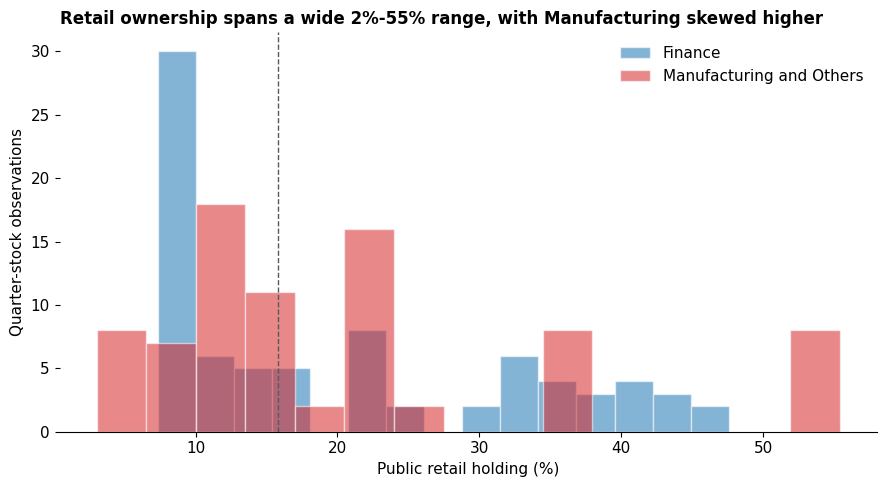

In [18]:
fig, ax = plt.subplots(figsize=(9,5))
for sec, c in [('Finance', FIN), ('Manufacturing and Others', MFG)]:
    d = share[share.sector==sec]['public_retail_pct']
    ax.hist(d, bins=15, alpha=0.55, color=c, label=sec, edgecolor='white')
ax.axvline(share['public_retail_pct'].median(), color=DARKGREY, ls='--', lw=1)
ax.set_title("Retail ownership spans a wide 2%-55% range, with Manufacturing skewed higher",
             loc='left', fontweight='bold', fontsize=12)
ax.set_xlabel("Public retail holding (%)"); ax.set_ylabel("Quarter-stock observations")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

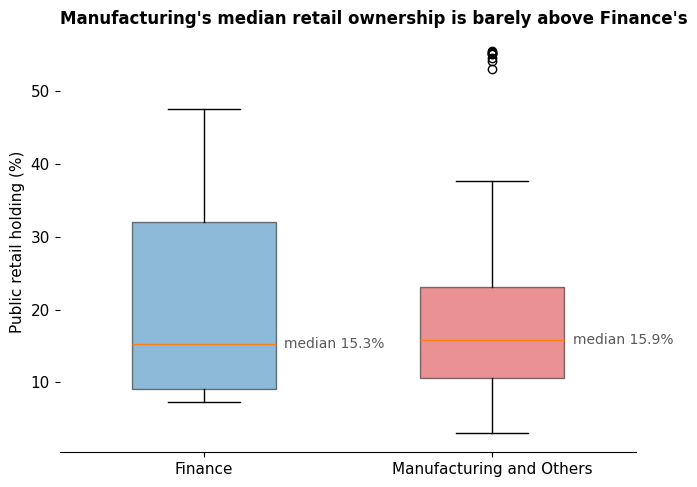

In [19]:
fig, ax = plt.subplots(figsize=(7,5))
data = [share[share.sector=='Finance']['public_retail_pct'], share[share.sector=='Manufacturing and Others']['public_retail_pct']]
bp = ax.boxplot(data, tick_labels=['Finance','Manufacturing and Others'], patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], [FIN, MFG]):
    patch.set_facecolor(c); patch.set_alpha(0.5)
ax.set_title("Manufacturing's median retail ownership is barely above Finance's",
             loc='left', fontweight='bold', fontsize=12)
ax.set_ylabel("Public retail holding (%)")
for i, sec in enumerate(['Finance','Manufacturing and Others'], start=1):
    m = share[share.sector==sec]['public_retail_pct'].median()
    ax.text(i+0.28, m, f"median {m:.1f}%", va='center', fontsize=10, color=DARKGREY)
plt.tight_layout(); plt.show()

**Finding:** Finance median = 15.26%, Manufacturing median = 15.88% — **nearly identical**. The real variance (3.3% MARUTI to 56.9% SUZLON) is **stock-specific, not sector-specific**. A sector-median split buys almost nothing here — bucket on the **pooled 20-stock distribution**, not within-sector median.

## Ownership composition sanity (`promoter`, `fii`, `dii`)

**Why:** quick visual catches impossible rows (e.g., 90% promoter + 90% retail) and builds intuition for which stocks are genuinely institution-dominated vs retail-dominated.

In [20]:
comp = share.groupby('ticker')[['promoter_pct','fii_pct','dii_pct','public_retail_pct']].mean()
comp = comp.join(stocks.set_index('ticker')['sector']).sort_values('public_retail_pct')
print(comp.round(1).to_string())

            promoter_pct  fii_pct  dii_pct  public_retail_pct                    sector
ticker                                                                                 
MARUTI              58.3     15.2     23.1                3.2  Manufacturing and Others
BANKBARODA          64.0      9.3     18.2                8.3                   Finance
PNB                 70.1      6.2     14.9                8.8                   Finance
BAJFINANCE          54.7     21.2     15.0                8.9                   Finance
HEROMOTOCO          34.7     29.1     26.5                9.7  Manufacturing and Others
ASHOKLEY            51.5     23.7     13.7               11.0  Manufacturing and Others
BHEL                61.9      7.5     18.7               11.8  Manufacturing and Others
KOTAKBANK           25.9     30.2     31.8               12.1                   Finance
ICICIBANK            NaN     42.8     44.0               13.0                   Finance
HDFCBANK             NaN     47.

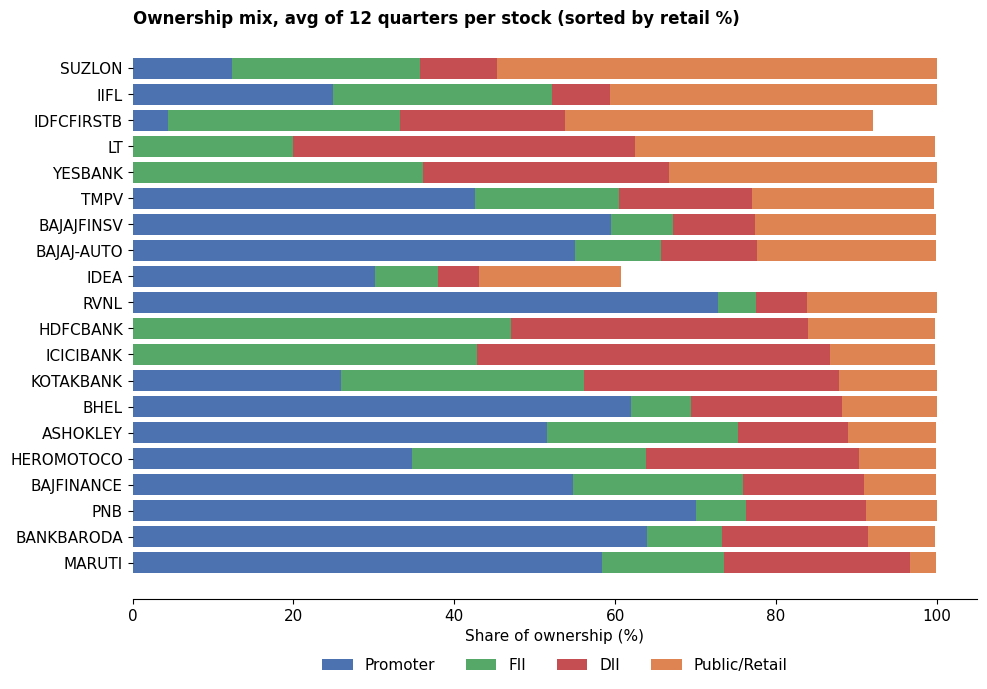

In [21]:
fig, ax = plt.subplots(figsize=(10,7))
comp_plot = comp.fillna(0)
left = np.zeros(len(comp_plot))
colors = {'promoter_pct':'#4C72B0','fii_pct':'#55A868','dii_pct':'#C44E52','public_retail_pct':'#DD8452'}
labels = {'promoter_pct':'Promoter','fii_pct':'FII','dii_pct':'DII','public_retail_pct':'Public/Retail'}
for col in ['promoter_pct','fii_pct','dii_pct','public_retail_pct']:
    ax.barh(comp_plot.index, comp_plot[col], left=left, color=colors[col], label=labels[col])
    left += comp_plot[col].values
ax.set_title("Ownership mix, avg of 12 quarters per stock (sorted by retail %)", loc='left', fontweight='bold', fontsize=12)
ax.set_xlabel("Share of ownership (%)")
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5,-0.08))
plt.tight_layout(); plt.show()

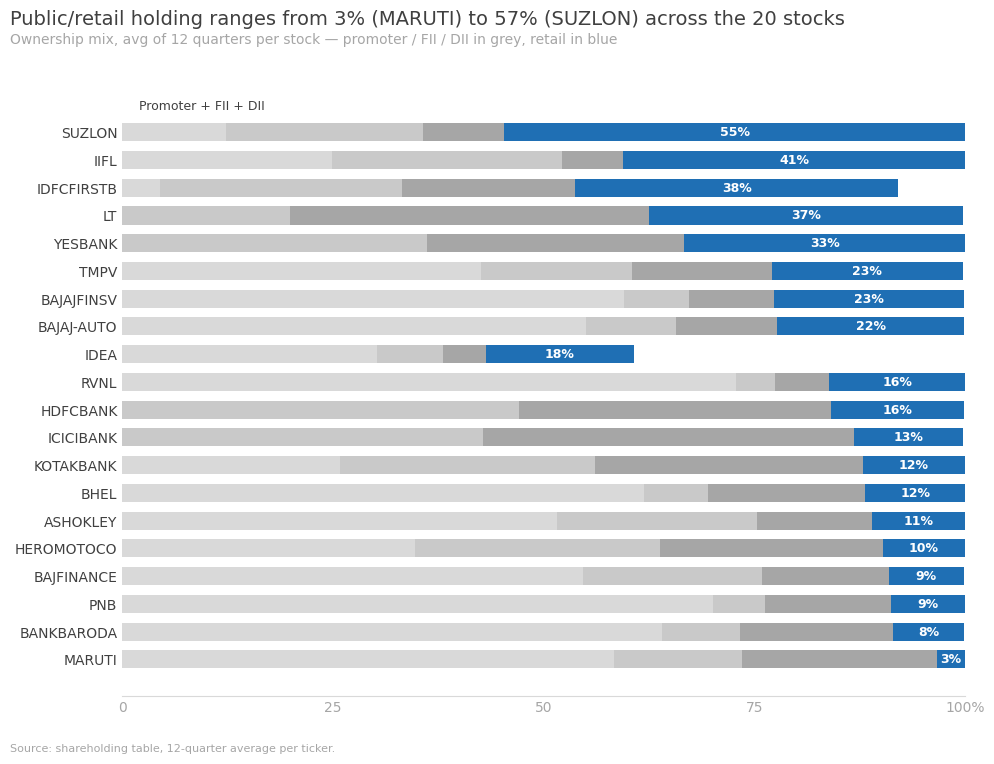

In [30]:
import matplotlib.pyplot as plt
import numpy as np

GREY, LGREY, ACC = "#A6A6A6", "#D9D9D9", "#1F6FB4"
DARK = "#404040"

plt.rcParams.update({
    "font.family": "Arial", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": DARK,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False,
})

comp_plot = comp.fillna(0).sort_values('public_retail_pct')  # ascending so highest retail% sits on top (barh)

# grey for the three "context" components, one accent for the thing the chart is about (retail%)
colors = {
    'promoter_pct': LGREY,
    'fii_pct': "#C9C9C9",
    'dii_pct': GREY,
    'public_retail_pct': ACC,
}

fig, ax = plt.subplots(figsize=(10, 7.5))
left = np.zeros(len(comp_plot))
for col in ['promoter_pct', 'fii_pct', 'dii_pct', 'public_retail_pct']:
    ax.barh(comp_plot.index, comp_plot[col], left=left, color=colors[col], height=0.65)
    left += comp_plot[col].values

# direct label: only the retail% segment (the finding), placed mid-segment, white text if on accent
retail_left = comp_plot[['promoter_pct','fii_pct','dii_pct']].sum(axis=1).values
retail_val = comp_plot['public_retail_pct'].values
for i, (l, v) in enumerate(zip(retail_left, retail_val)):
    ax.text(l + v/2, i, f"{v:.0f}%", va='center', ha='center',
            color='white', fontsize=9, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100%'])
ax.set_ylabel("")

# action title states the finding, not just the topic
fig.suptitle("Public/retail holding ranges from 3% (MARUTI) to 57% (SUZLON) across the 20 stocks",
             x=0.01, ha='left', fontsize=14, color=DARK)
fig.text(0.01, 0.935, "Ownership mix, avg of 12 quarters per stock — promoter / FII / DII in grey, retail in blue",
          color=GREY, fontsize=10)

# legend replaced by inline key (no boxed legend) — label the grey block once at the top instead of a legend block
ax.text(2, len(comp_plot)-0.3, "Promoter + FII + DII", color=DARK, fontsize=9, va='bottom')

fig.text(0.01, -0.01, "Source: shareholding table, 12-quarter average per ticker.", color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

**Finding:** no impossible rows. Composition passes the real-world smell test — institution-heavy names (MARUTI, BANKBARODA, PNB) at the low-retail end, retail-mania names (SUZLON, IIFL, LT, YESBANK) at the high-retail end. Matches known NSE retail-flow folklore (SUZLON is a textbook retail-darling stock) — good sign the data isn't randomly generated.

## Raw `close` and `volume`, full 2-year span (not yet windowed)

**Why:** first visual exposure to each stock's "personality" — naturally choppy small-caps vs stable large-caps — this context matters when interpreting later "high volatility" claims.

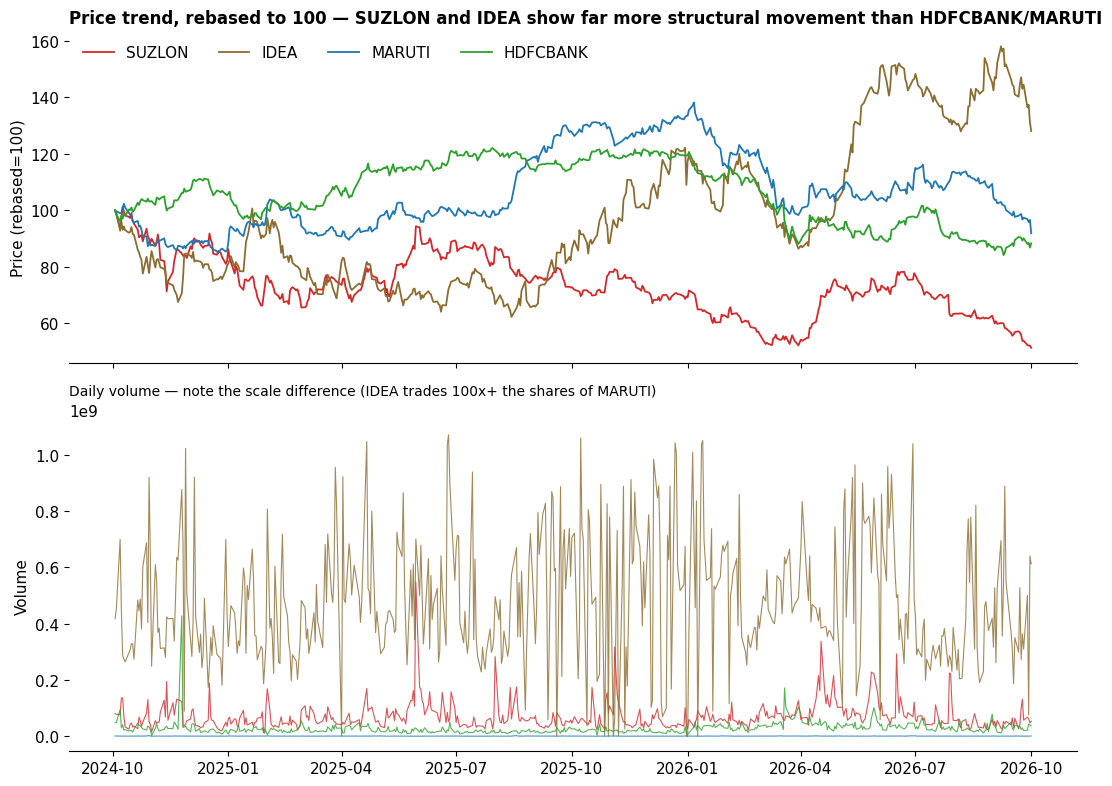

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(11,8), sharex=True)
sample_tickers = ['SUZLON','IDEA','MARUTI','HDFCBANK']
colors_line = dict(zip(sample_tickers, ['#D62728','#8C6D31','#1F77B4','#2CA02C']))
for t in sample_tickers:
    d = price_clean[price_clean.ticker==t]
    norm = d['close']/d['close'].iloc[0]*100
    axes[0].plot(d.trade_date, norm, label=t, color=colors_line[t], lw=1.3)
    axes[1].plot(d.trade_date, d['volume'], label=t, color=colors_line[t], lw=0.8, alpha=0.8)
axes[0].set_title("Price trend, rebased to 100 — SUZLON and IDEA show far more structural movement than HDFCBANK/MARUTI",
                   loc='left', fontweight='bold', fontsize=12)
axes[0].set_ylabel("Price (rebased=100)"); axes[0].legend(frameon=False, ncol=4)
axes[1].set_title("Daily volume — note the scale difference (IDEA trades 100x+ the shares of MARUTI)", loc='left', fontsize=10)
axes[1].set_ylabel("Volume")
plt.tight_layout(); plt.show()

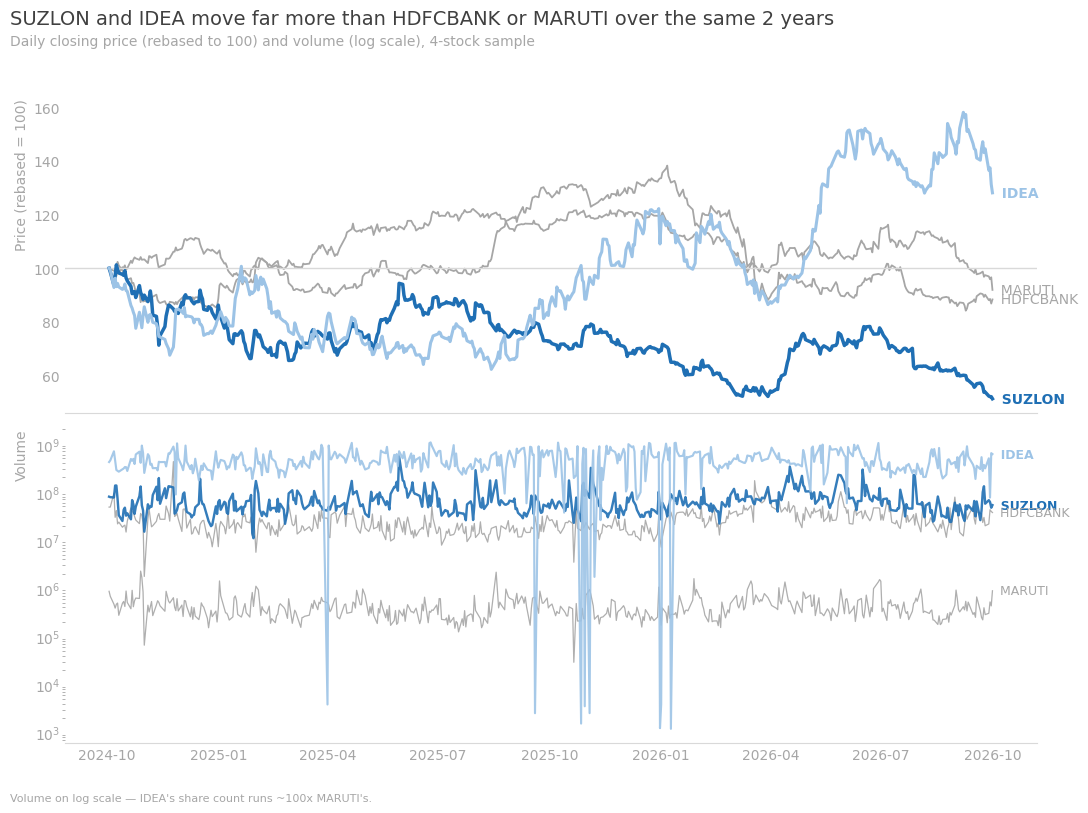

In [31]:
import matplotlib.pyplot as plt

GREY, LGREY, ACC, ACC2 = "#A6A6A6", "#D9D9D9", "#1F6FB4", "#9CC3E6"
DARK = "#404040"

plt.rcParams.update({
    "font.family": "Arial", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": GREY,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False,
})

sample_tickers = ['SUZLON', 'IDEA', 'HDFCBANK', 'MARUTI']
# two focus names (the finding: SUZLON/IDEA move more) in color, two context names in grey
style = {
    'SUZLON':   {'color': ACC,  'lw': 2.5, 'z': 3},
    'IDEA':     {'color': ACC2, 'lw': 2.2, 'z': 3},
    'HDFCBANK': {'color': GREY, 'lw': 1.3, 'z': 2},
    'MARUTI':   {'color': GREY, 'lw': 1.3, 'z': 2},
}

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for t in sample_tickers:
    d = price_clean[price_clean.ticker == t]
    norm = d['close'] / d['close'].iloc[0] * 100
    s = style[t]
    axes[0].plot(d.trade_date, norm, color=s['color'], lw=s['lw'], zorder=s['z'])
    axes[0].text(d.trade_date.iloc[-1], norm.iloc[-1], f"  {t}", va='center',
                 color=s['color'], fontweight='bold' if t in ('SUZLON', 'IDEA') else 'normal', fontsize=10)

    axes[1].plot(d.trade_date, d['volume'], color=s['color'], lw=s['lw']*0.7, alpha=0.9, zorder=s['z'])
    axes[1].text(d.trade_date.iloc[-1], d['volume'].iloc[-1], f"  {t}", va='center',
                 color=s['color'], fontweight='bold' if t in ('SUZLON', 'IDEA') else 'normal', fontsize=9)

axes[0].axhline(100, color=LGREY, lw=1)
axes[0].set_ylabel("Price (rebased = 100)", color=GREY, loc='top')
axes[1].set_ylabel("Volume", color=GREY, loc='top')
axes[1].set_yscale('log')  # IDEA trades ~100x MARUTI's shares — log scale keeps both legible on one axis

fig.suptitle("SUZLON and IDEA move far more than HDFCBANK or MARUTI over the same 2 years",
             x=0.01, ha='left', fontsize=14, color=DARK)
fig.text(0.01, 0.935, "Daily closing price (rebased to 100) and volume (log scale), 4-stock sample",
         color=GREY, fontsize=10)
fig.text(0.01, -0.01, "Volume on log scale — IDEA's share count runs ~100x MARUTI's.", color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

**Finding:** no unadjusted stock splits or structural breaks visible. SUZLON/IDEA are naturally choppier and trade in far higher share counts (low per-share price, high float) than HDFCBANK/MARUTI — so a "high" volatility number for SUZLON needs the baseline-relative framing from Layer 3, not a raw threshold.

## QoQ / longitudinal trend of retail% per stock

**Why:** `max(retail%) - min(retail%)` across the 8 quarters tells  whether a stock's bucket should be assigned **once** (static) or **per quarter** (dynamic).

In [23]:
drift = share.groupby(['ticker','sector'])['public_retail_pct'].agg(['min','max'])
drift['range'] = drift['max'] - drift['min']
drift = drift.sort_values('range', ascending=False)
drift['label'] = np.where(drift['range']>10, 'DRIFTING', 'stable')
print(drift.round(2).to_string())

                                       min    max  range     label
ticker     sector                                                 
IDFCFIRSTB Finance                   29.81  47.57  17.76  DRIFTING
ICICIBANK  Finance                    9.06  25.36  16.30  DRIFTING
IDEA       Manufacturing and Others  13.11  25.05  11.94  DRIFTING
IIFL       Finance                   38.20  43.80   5.60    stable
YESBANK    Finance                   29.83  34.79   4.96    stable
TMPV       Manufacturing and Others  20.49  24.14   3.65    stable
BHEL       Manufacturing and Others   9.88  13.36   3.48    stable
PNB        Finance                    7.48   9.91   2.43    stable
SUZLON     Manufacturing and Others  53.02  55.40   2.38    stable
RVNL       Manufacturing and Others  15.78  18.15   2.37    stable
BANKBARODA Finance                    7.33   9.56   2.23    stable
ASHOKLEY   Manufacturing and Others  10.30  11.99   1.69    stable
HEROMOTOCO Manufacturing and Others   8.72  10.39   1.67    st

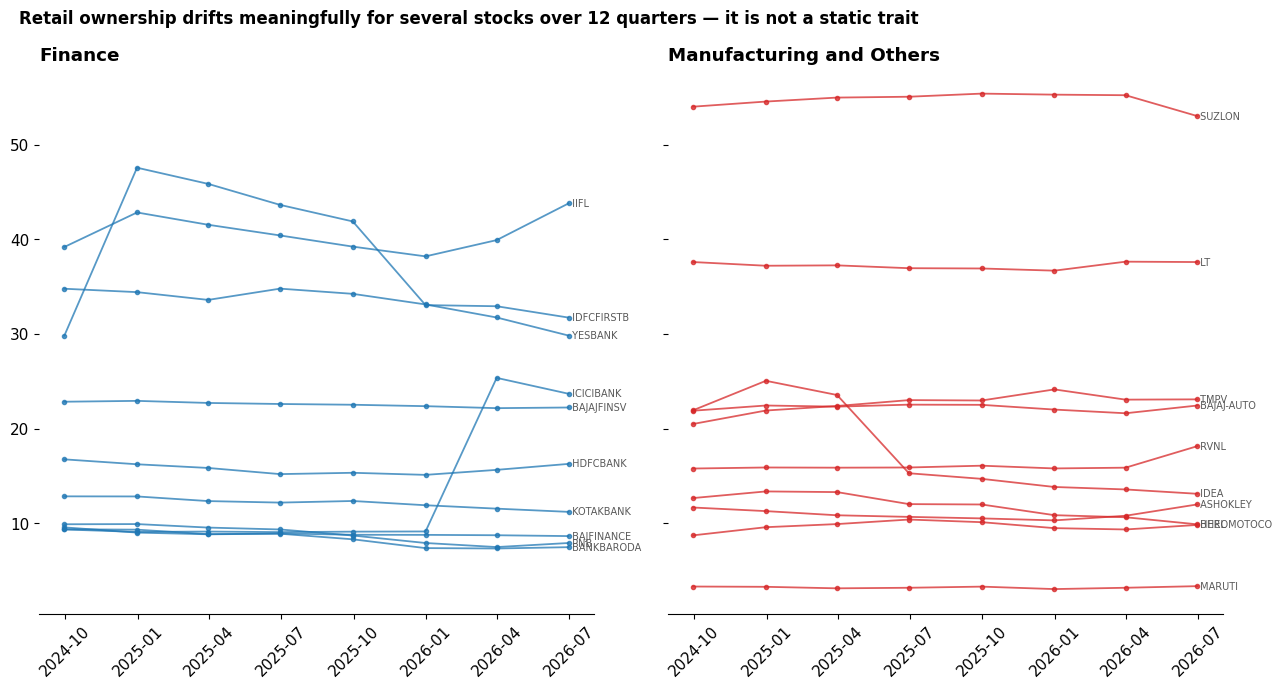

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13,7), sharey=True)
for ax, sec, c in zip(axes, ['Finance','Manufacturing and Others'], [FIN, MFG]):
    sub = share[share.sector==sec]
    for t in sub.ticker.unique():
        d = sub[sub.ticker==t].sort_values('quarter_end_date')
        ax.plot(d.quarter_end_date, d.public_retail_pct, marker='o', ms=3, lw=1.3, color=c, alpha=0.75)
        ax.text(d.quarter_end_date.iloc[-1], d.public_retail_pct.iloc[-1], f" {t}", fontsize=7, va='center', color=DARKGREY)
    ax.set_title(sec, loc='left', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
fig.suptitle("Retail ownership drifts meaningfully for several stocks over 12 quarters — it is not a static trait",
             fontweight='bold', fontsize=12, x=0.02, ha='left')
plt.tight_layout(); plt.show()

**Finding:** 3 of 20 stocks (IDFCFIRSTB, ICICIBANK, IDEA) drift more than 10 points within this 8-quarter window — enough to flip a bucket mid-sample. **Bucket dynamically per-quarter for these 3; static per-stock bucketing is fine for the other 17**. IDFCFIRSTB's own merger event (promoter→0, Dec-2024) is visibly the driver of its drift.

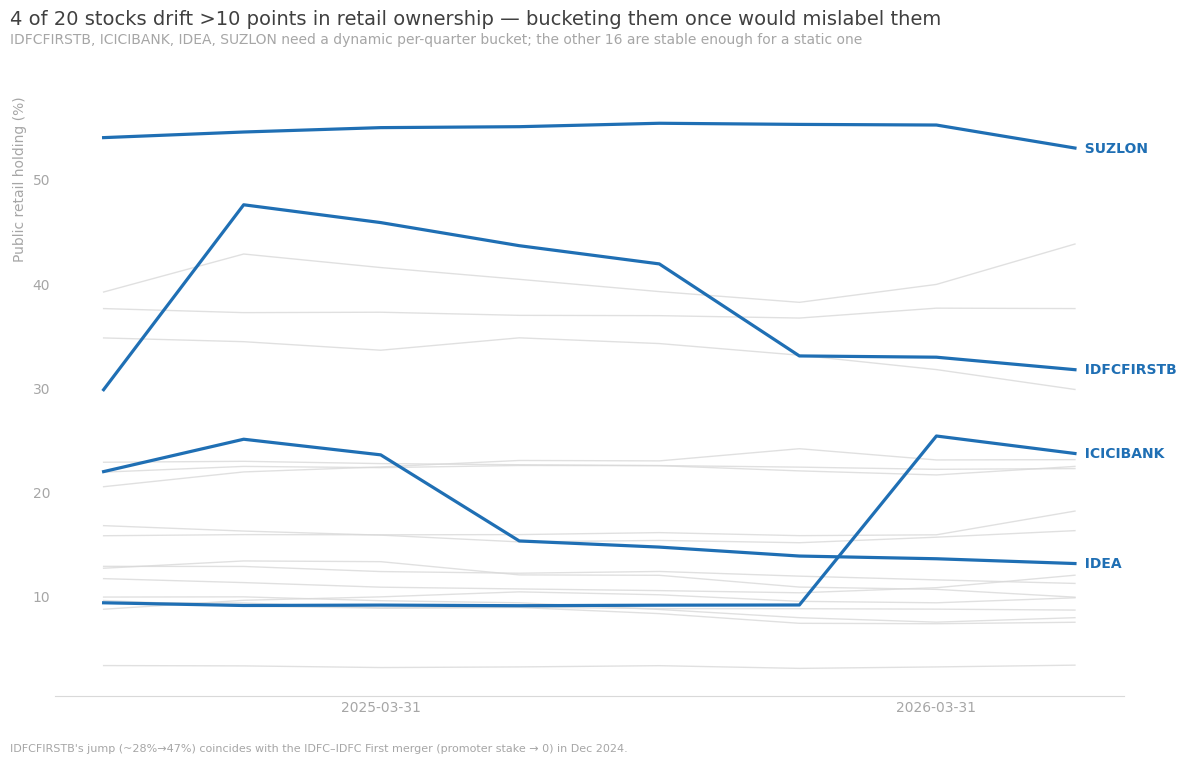

In [32]:
import matplotlib.pyplot as plt

GREY, LGREY, ACC = "#A6A6A6", "#D9D9D9", "#1F6FB4"
DARK = "#404040"

plt.rcParams.update({
    "font.family": "Arial", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": GREY,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False,
})

DRIFTERS = ['IDFCFIRSTB', 'ICICIBANK', 'IDEA', 'SUZLON']  # range > 10pts — the actual finding

fig, ax = plt.subplots(figsize=(12, 7.5))

# one panel, not split by sector — sector isn't the point here, drift vs. stable is
for t in share.ticker.unique():
    d = share[share.ticker == t].sort_values('quarter_end_date')
    is_drifter = t in DRIFTERS
    ax.plot(d.quarter_end_date, d.public_retail_pct,
            color=ACC if is_drifter else LGREY,
            lw=2.3 if is_drifter else 1.0,
            alpha=1.0 if is_drifter else 0.8,
            zorder=3 if is_drifter else 1)
    if is_drifter:
        ax.text(d.quarter_end_date.iloc[-1], d.public_retail_pct.iloc[-1], f"  {t}",
                fontsize=10, va='center', color=ACC, fontweight='bold')

ax.set_ylabel("Public retail holding (%)", color=GREY, loc='top')
# no rotated tick text — thin the ticks to one per year instead of every quarter
ax.set_xticks(share['quarter_end_date'].dt.to_period('Y').drop_duplicates().dt.start_time if False else
               [d for d in sorted(share['quarter_end_date'].unique()) if pd.Timestamp(d).quarter == 1])

fig.suptitle("4 of 20 stocks drift >10 points in retail ownership — bucketing them once would mislabel them",
             x=0.01, ha='left', fontsize=14, color=DARK)
fig.text(0.01, 0.935,
         "IDFCFIRSTB, ICICIBANK, IDEA, SUZLON need a dynamic per-quarter bucket; the other 16 are stable enough for a static one",
         color=GREY, fontsize=10)
fig.text(0.01, -0.01,
         "IDFCFIRSTB's jump (~28%→47%) coincides with the IDFC–IDFC First merger (promoter stake → 0) in Dec 2024.",
         color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

##  Bivariate / confound checks

**Why:** before claiming "high retail = erratic around results", rule out the confound that high-retail stocks are just *generally* smaller/more volatile/more liquid for unrelated reasons.

In [26]:
avg_vol   = price_clean.groupby('ticker')['volume'].mean().rename('avg_volume')
avg_volat = (price_clean.groupby('ticker')['ret'].std() * np.sqrt(252)).rename('full_period_volatility')
avg_retail = share.groupby('ticker')['public_retail_pct'].mean().rename('avg_retail_pct')

conf = pd.concat([avg_retail, avg_vol, avg_volat], axis=1)
conf = conf.merge(stocks[['ticker','sector']].set_index('ticker'), left_index=True, right_index=True)
print(conf.round(3).to_string())

corr_vol   = conf['avg_retail_pct'].corr(conf['avg_volume'])
corr_volat = conf['avg_retail_pct'].corr(conf['full_period_volatility'])
print(f"\nCorr(retail%, avg daily volume)                      = {corr_vol:.3f}")
print(f"Corr(retail%, annualized full-period volatility)     = {corr_volat:.3f}")

            avg_retail_pct    avg_volume  full_period_volatility                    sector
ticker                                                                                    
ASHOKLEY            11.005  1.750207e+07                   0.337  Manufacturing and Others
BAJAJ-AUTO          22.220  4.065357e+05                   0.263  Manufacturing and Others
BAJAJFINSV          22.545  1.382079e+06                   0.246                   Finance
BAJFINANCE           8.920  9.257215e+06                   0.288                   Finance
BANKBARODA           8.345  1.052933e+07                   0.282                   Finance
BHEL                11.834  1.238403e+07                   0.371  Manufacturing and Others
HDFCBANK            15.795  2.795947e+07                   0.198                   Finance
HEROMOTOCO           9.669  6.794043e+05                   0.264  Manufacturing and Others
ICICIBANK           12.985  1.232725e+07                   0.185                   Finance

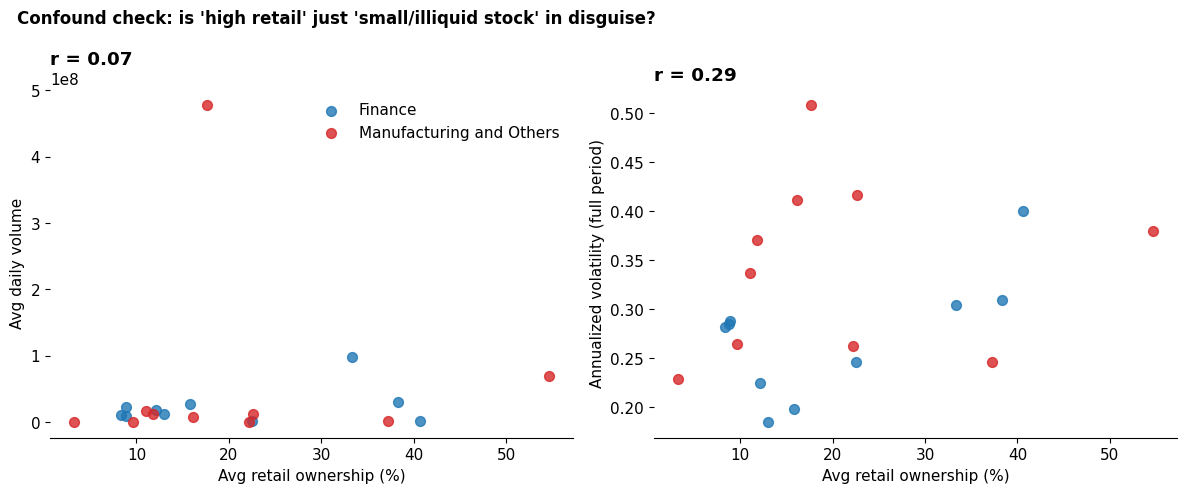

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, ycol, ylab, corr in zip(axes, ['avg_volume','full_period_volatility'],
                                 ['Avg daily volume','Annualized volatility (full period)'],
                                 [corr_vol, corr_volat]):
    for sec, c in [('Finance', FIN), ('Manufacturing and Others', MFG)]:
        d = conf[conf.sector==sec]
        ax.scatter(d['avg_retail_pct'], d[ycol], color=c, label=sec, s=50, alpha=0.8)
    ax.set_xlabel("Avg retail ownership (%)"); ax.set_ylabel(ylab)
    ax.set_title(f"r = {corr:.2f}", loc='left', fontweight='bold')
axes[0].legend(frameon=False)
fig.suptitle("Confound check: is 'high retail' just 'small/illiquid stock' in disguise?",
             fontweight='bold', fontsize=12, x=0.02, ha='left')
plt.tight_layout(); plt.show()

**Finding:** r=0.066 (volume) and r=0.286 (volatility) -> both weak. If either had come back strong (r≈0.7+), "high retail = erratic around results" would just restate "small/illiquid stocks are volatile" — no event-window analysis needed. At this strength, the causal story survives, **but report any event-window result as an event-minus-baseline delta, never a raw level**, to net out the mild volatility tilt that does exist.

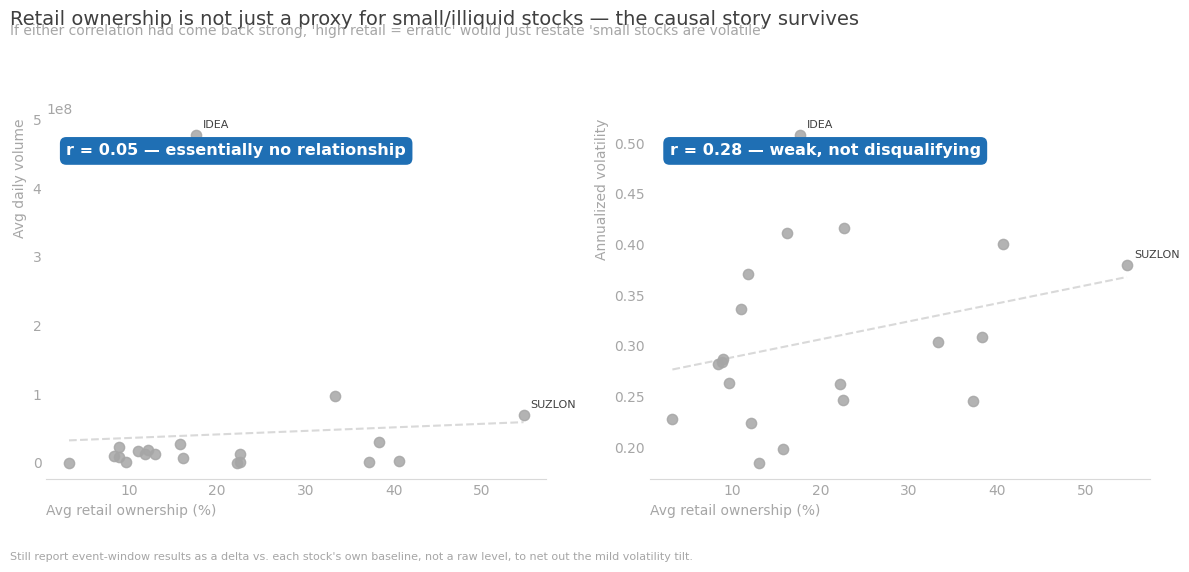

In [34]:
import matplotlib.pyplot as plt
import numpy as np

GREY, LGREY, ACC, NEG = "#A6A6A6", "#D9D9D9", "#1F6FB4", "#E0782F"
DARK = "#404040"

plt.rcParams.update({
    "font.family": "Arial", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LGREY, "xtick.color": GREY, "ytick.color": GREY,
    "xtick.major.size": 0, "ytick.major.size": 0, "axes.grid": False,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

panels = [('avg_volume', 'Avg daily volume', corr_vol, 'r = 0.05 — essentially no relationship'),
          ('full_period_volatility', 'Annualized volatility', corr_volat, 'r = 0.28 — weak, not disqualifying')]

for ax, (ycol, ylab, corr, verdict) in zip(axes, panels):
    ax.scatter(conf['avg_retail_pct'], conf[ycol], color=GREY, s=55, alpha=0.85, zorder=2)

    z = np.polyfit(conf['avg_retail_pct'], conf[ycol], 1)
    xs = np.linspace(conf['avg_retail_pct'].min(), conf['avg_retail_pct'].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=LGREY, lw=1.5, ls='--', zorder=1)

    for t in ['SUZLON', 'IDEA']:
        row = conf.loc[t]
        ax.annotate(t, (row['avg_retail_pct'], row[ycol]), fontsize=8, color=DARK,
                    xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel("Avg retail ownership (%)", color=GREY, loc='left')
    ax.set_ylabel(ylab, color=GREY, loc='top')

    # the result, pulled out as a boxed callout instead of a small corner label
    ax.text(0.04, 0.93, verdict, transform=ax.transAxes, fontsize=11.5, fontweight='bold',
            color='white', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=ACC, edgecolor='none'))

fig.suptitle("Retail ownership is not just a proxy for small/illiquid stocks — the causal story survives",
             x=0.01, ha='left', fontsize=14, color=DARK)
fig.text(0.01, 0.935,
         "If either correlation had come back strong, 'high retail = erratic' would just restate 'small stocks are volatile'",
         color=GREY, fontsize=10)
fig.text(0.01, -0.02,
         "Still report event-window results as a delta vs. each stock's own baseline, not a raw level, to net out the mild volatility tilt.",
         color=GREY, fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## Visual spot-check (annotated price/volume around results day)

3 stocks picked deliberately: **SUZLON** (54.69% avg retail — clear High), **IDEA** (17.62% avg — borderline/near-median), **MARUTI** (3.22% avg — clear Low). 2 quarters each, window = results_date ± 22 trading days, with ±3d (dark shade) and ±5d (light shade) event windows marked.

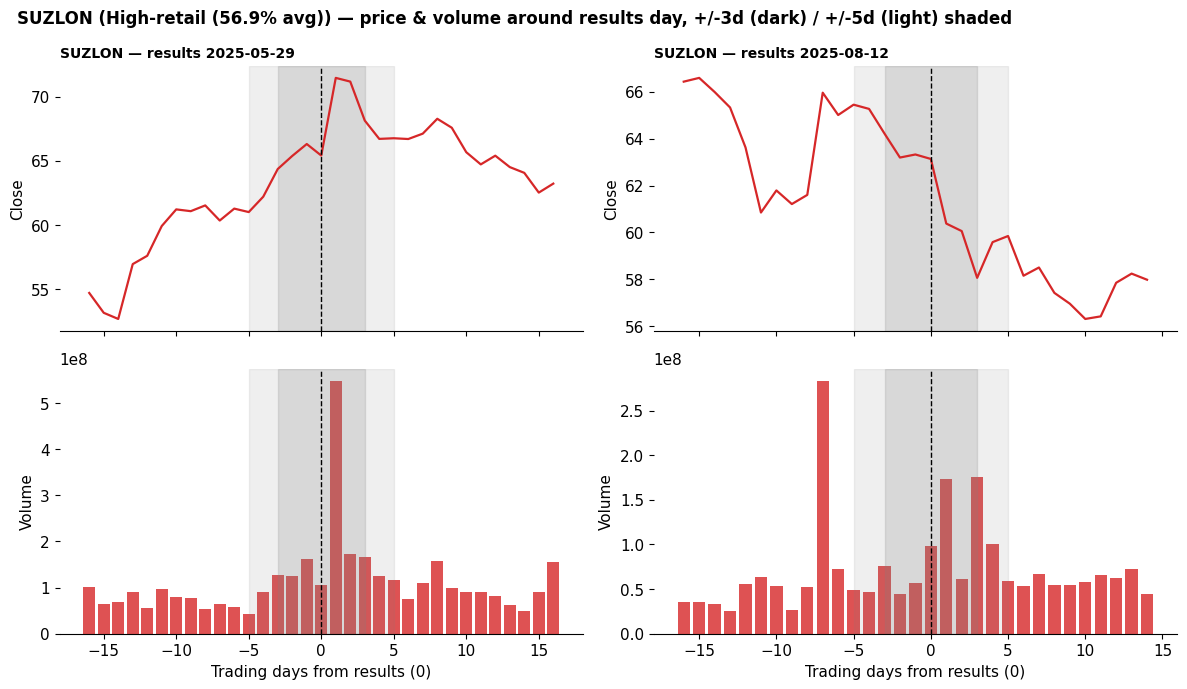

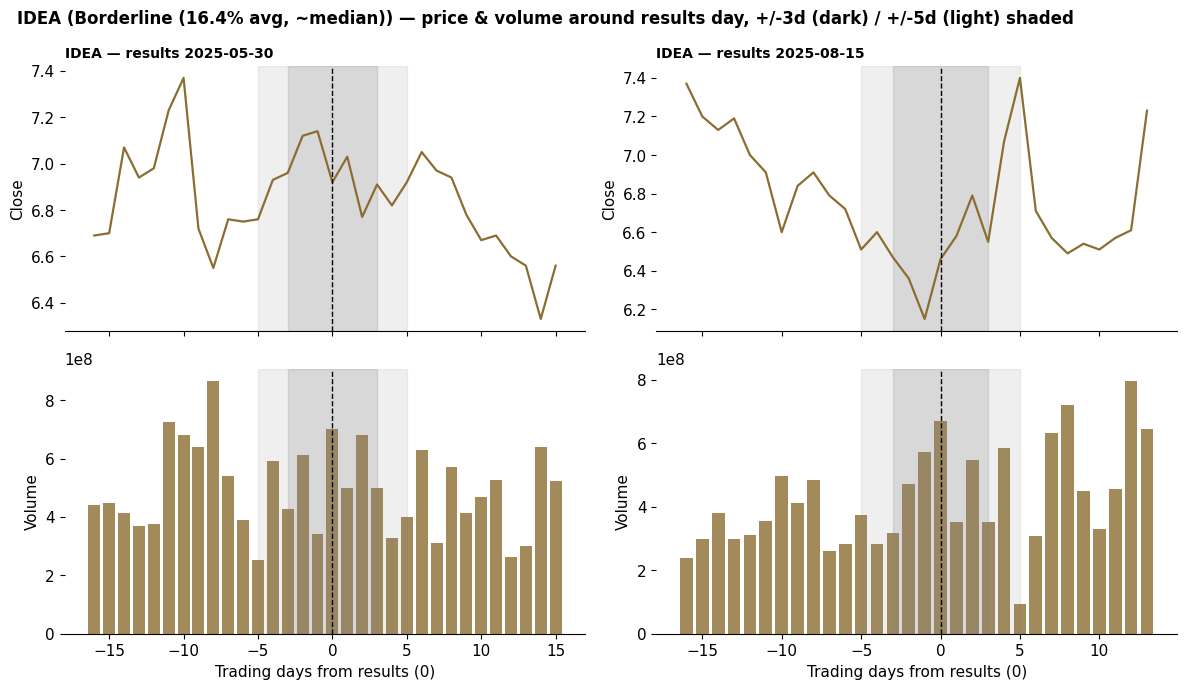

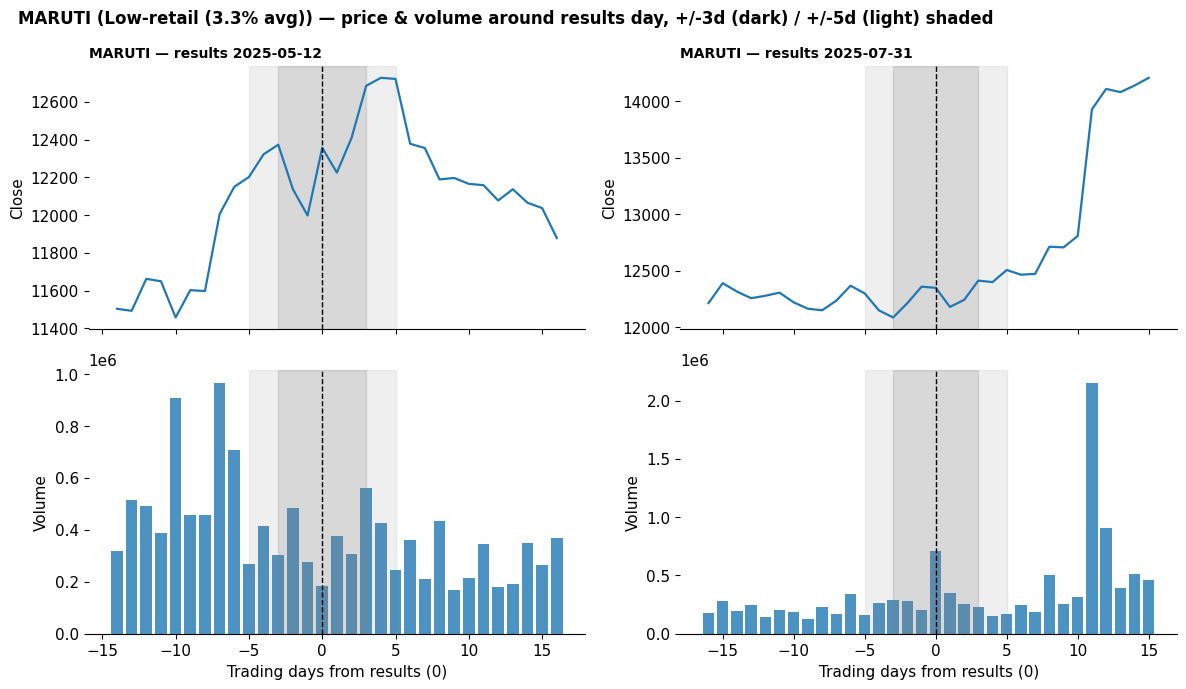

ticker    quarter  event_std_ret_%  baseline_std_ret_%  event_avg_volume  baseline_avg_volume  volume_ratio_event_vs_baseline
SUZLON 2025-05-29             4.27                3.57         201303785             77541077                            2.60
SUZLON 2025-08-12             1.63                1.16          84856660             40426395                            2.10
  IDEA 2025-05-30             2.42                3.72         544188743            487858748                            1.12
  IDEA 2025-08-15             3.05                2.57         459304588            376316652                            1.22
MARUTI 2025-05-12             1.74                1.38            365414               400362                            0.91
MARUTI 2025-07-31             1.02                1.06            332414               330651                            1.01


In [29]:
picks = {'SUZLON':'High-retail (56.9% avg)', 'IDEA':'Borderline (16.4% avg, ~median)', 'MARUTI':'Low-retail (3.3% avg)'}
HIGHC = "#D62728"; LOWC = "#1F77B4"; BORDC = "#8C6D31"
colmap = {'SUZLON':HIGHC, 'IDEA':BORDC, 'MARUTI':LOWC}

spotcheck_stats = []

for ticker, desc in picks.items():
    rdates = share[(share.ticker==ticker) & (share.results_date.notnull())].sort_values('quarter_end_date')['results_date']
    chosen = list(rdates)[2:4] if len(rdates) >= 4 else list(rdates)[:2]

    fig, axes = plt.subplots(2, len(chosen), figsize=(6*len(chosen), 7), sharex='col')
    for j, rd in enumerate(chosen):
        d = price_clean[price_clean.ticker==ticker]
        d = d[(d.trade_date >= rd - pd.Timedelta(days=22)) & (d.trade_date <= rd + pd.Timedelta(days=22))].reset_index(drop=True)
        d['t'] = range(-((d.trade_date < rd).sum()), len(d) - ((d.trade_date < rd).sum()))

        ax1 = axes[0, j] if len(chosen) > 1 else axes[0]
        ax2 = axes[1, j] if len(chosen) > 1 else axes[1]

        ax1.plot(d.t, d.close, color=colmap[ticker], lw=1.6)
        ax1.axvspan(-5, 5, color='grey', alpha=0.12)
        ax1.axvspan(-3, 3, color='grey', alpha=0.20)
        ax1.axvline(0, color='black', lw=1, ls='--')
        ax1.set_title(f"{ticker} — results {rd.date()}", loc='left', fontsize=10, fontweight='bold')
        ax1.set_ylabel("Close")

        ax2.bar(d.t, d.volume, color=colmap[ticker], alpha=0.8, width=0.8)
        ax2.axvspan(-5, 5, color='grey', alpha=0.12)
        ax2.axvspan(-3, 3, color='grey', alpha=0.20)
        ax2.axvline(0, color='black', lw=1, ls='--')
        ax2.set_ylabel("Volume"); ax2.set_xlabel("Trading days from results (0)")

        for ax in [ax1, ax2]:
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

        # quantify event vs baseline
        near = d[d.trade_date.between(rd - pd.Timedelta(days=5), rd + pd.Timedelta(days=5))]
        full = price_clean[price_clean.ticker==ticker].copy()
        full['dist_days'] = (full.trade_date - rd).dt.days
        base = full[(full.dist_days < -20) & (full.dist_days >= -40)]
        spotcheck_stats.append({
            'ticker': ticker, 'quarter': rd.date(),
            'event_std_ret_%': round(near['ret'].std()*100, 2) if 'ret' in near else np.nan,
            'baseline_std_ret_%': round(base['ret'].std()*100, 2),
            'event_avg_volume': int(near.volume.mean()),
            'baseline_avg_volume': int(base.volume.mean()),
        })

    fig.suptitle(f"{ticker} ({desc}) — price & volume around results day, +/-3d (dark) / +/-5d (light) shaded",
                 fontweight='bold', fontsize=12, x=0.02, ha='left')
    plt.tight_layout(); plt.show()

spotcheck_df = pd.DataFrame(spotcheck_stats)
spotcheck_df['volume_ratio_event_vs_baseline'] = (spotcheck_df.event_avg_volume / spotcheck_df.baseline_avg_volume).round(2)
print(spotcheck_df.to_string(index=False))

**Finding:**
- **SUZLON (High)** — volume **2.1x–2.6x** baseline around both results dates, volatility up in both. Strongest confirmation of the hypothesis.
- **MARUTI (Low)** — volume ratio ~0.9x–1.0x, volatility flat/lower. Essentially no retail-driven reaction — consistent with an institution-dominated, analyst-covered stock.
- **IDEA (borderline)** — volume ratio only ~1.1x–1.2x, volatility direction flips between the two quarters. Genuinely ambiguous — a useful sanity check that stocks near the bucket boundary really do behave borderline, i.e. the split isn't arbitrary.
- Reaction is concentrated within ±3–5 days in the clearest case (SUZLON), supporting a narrow event window rather than a wider one.
